# **Efficient Uncertainty‑Guided Sensor Placement for Air Quality Mapping**

**Problem**:
    
    - Deploying air quality sensors is costly. Given a limited budget for new sensors, where should we place them to maximally improve the accuracy of a spatial interpolation model?

**Existing gap**:

    - Common approaches (random, uniform grid) ignore model uncertainty and are computationally inefficient for large candidate sets.
    - Greedy uncertainty‑based selection is powerful but often implemented without spatial data structures, leading to repeated costly distance checks.

**Our contribution**:

    - Use a Gaussian Process (GP) to model the spatial field and provide uncertainty (predictive variance).
    - Accelerate the greedy selection with an **R‑tree** spatial index to quickly filter out candidate points too close to existing sensors (ensuring spatial diversity).
    - Use a priority queue (max‑heap) to retrieve the top‑variance candidates efficiently.

We benchmark against random and uniform selection, showing that our method yields lower mapping error with acceptable computational overhead.

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
numpy: 2.0.2
scipy: 1.16.3
sklearn: 1.6.1
matplotlib: 3.10.0

=== Final RMSE after 10 new sensors (mean ± std, n=30) ===
random  : 0.0650 ± 0.0183
uniform : 0.0589 ± 0.0127
greedy  : 0.0503 ± 0.0082

=== Statistical Significance ===
Random vs Greedy: paired t-test p=0.00007, Wilcoxon p=0.00001
Uniform vs Greedy: paired t-test p=0.00042, Wilcoxon p=0.00006
95% CI for mean RMSE reduction (Greedy - Random): ConfidenceInterval(low=np.float64(-0.02196543406613352), high=np.float64(-0.009411066889870902))
Cohen's d (Random - Greedy): 1.03 (interpretation: >0.8 = large effect)


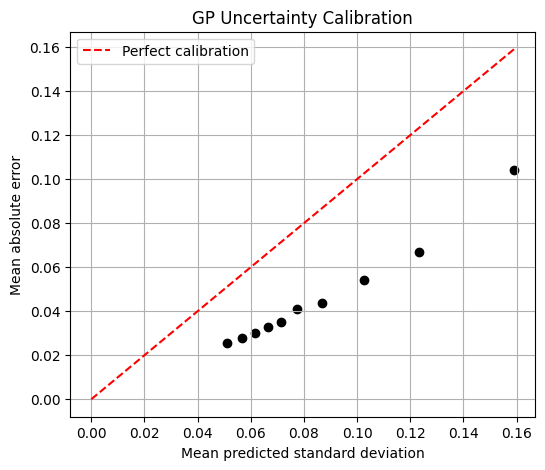

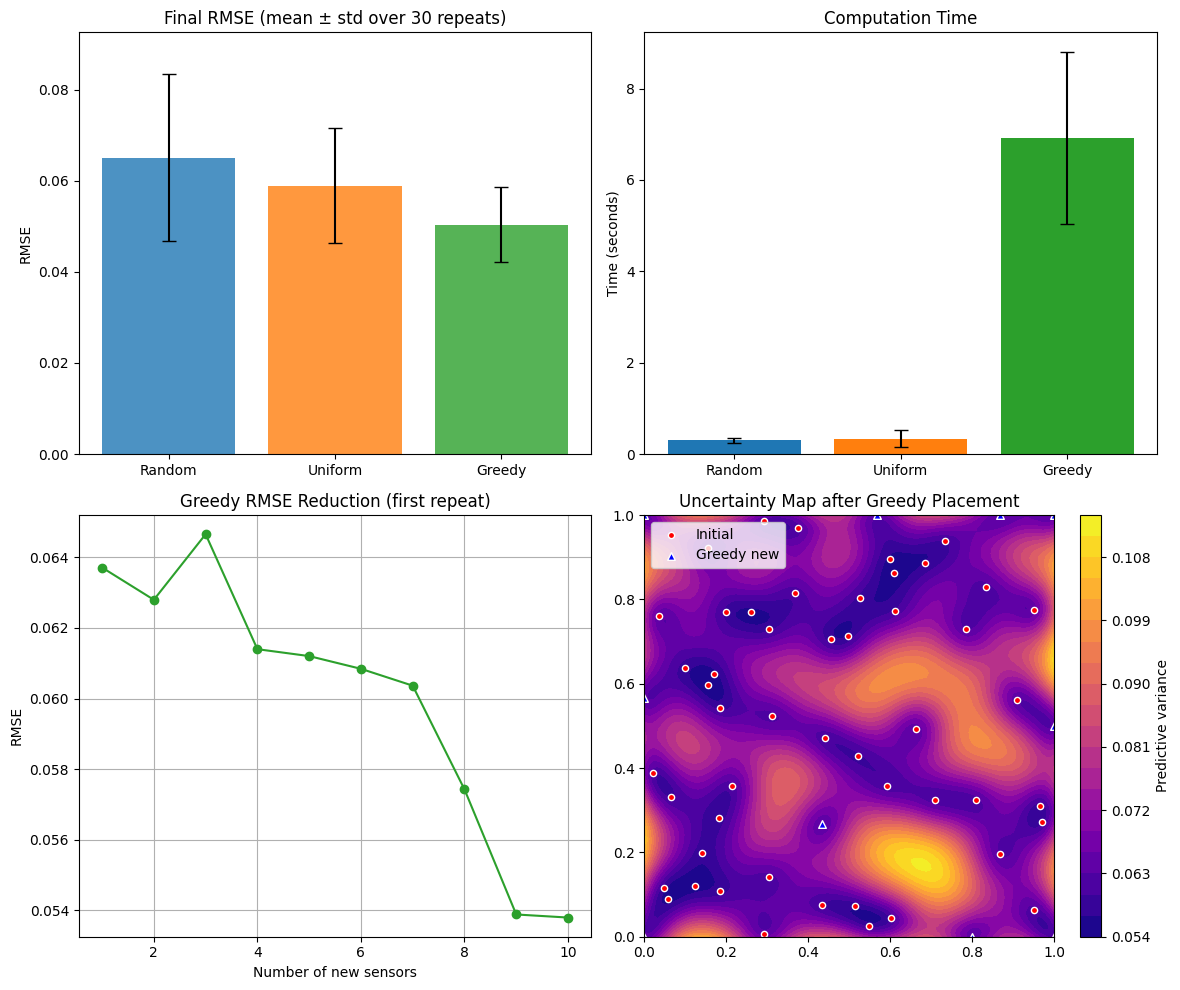

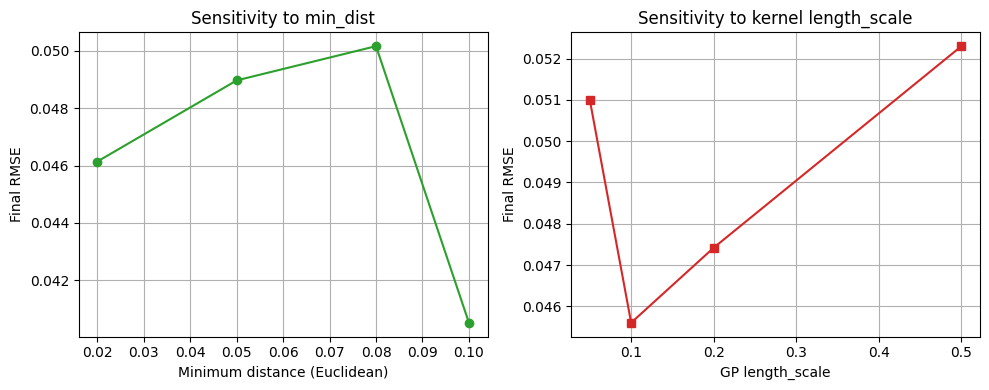


LIMITATIONS AND FUTURE WORK

1. Synthetic smooth field – real pollution has sharp gradients, non‑stationarity, and anisotropy.
2. Known noise level and kernel form – in practice these must be estimated from data, adding uncertainty.
3. Greedy selection is myopic (not globally optimal), though submodularity guarantees near‑optimality.
4. Computation scales as O(k·n³) with total sensors n – for >500 initial sensors, sparse GPs are needed.
5. No temporal dimension – real monitoring requires dynamic placement over time (e.g., adaptive sensing).
6. Euclidean distance constraint may discard informative points in highly variable micro‑environments.

Future work:
- Validate on real urban air quality data with mobile sensors.
- Extend to batch Bayesian optimisation (select k points jointly).
- Incorporate auxiliary covariates (traffic, land use) into a heteroscedastic GP.
- Develop a real‑time adaptive resampling strategy.



In [ ]:
# ### Reproducibility & Environment
import sys, platform, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import ttest_rel, wilcoxon, bootstrap
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
import time
import warnings
warnings.filterwarnings('ignore')

print("Python version:", sys.version)
print("Platform:", platform.platform())
for pkg in ['numpy', 'scipy', 'sklearn', 'matplotlib']:
    print(f"{pkg}: {importlib.import_module(pkg).__version__}")


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def generate_true_field(x, y, peaks=[(0.3,0.3,1.0), (0.7,0.2,0.8), (0.5,0.8,1.2)], trend=0.5):
    X, Y = np.meshgrid(x, y, indexing='ij')
    field = np.zeros_like(X)
    for x0, y0, amp in peaks:
        field += amp * np.exp(-((X-x0)**2 + (Y-y0)**2) / 0.05)
    field += trend * (X + Y)
    return field

n_grid = 100
x_grid = np.linspace(0, 1, n_grid)
y_grid = np.linspace(0, 1, n_grid)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')
true_field = generate_true_field(x_grid, y_grid)

n_initial = 50
noise_std = 0.05

# Candidate locations (subsampled grid for manageable compute)
n_candidates = 1000
cand_x = np.linspace(0, 1, int(np.sqrt(n_candidates)))
cand_y = np.linspace(0, 1, int(np.sqrt(n_candidates)))
cand_xx, cand_yy = np.meshgrid(cand_x, cand_y, indexing='ij')
candidate_coords = np.vstack([cand_xx.ravel(), cand_yy.ravel()]).T

# Dense test grid for evaluation
test_coords = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T
test_true = true_field.ravel()


def evaluate_sensors(train_coords, train_z, test_coords, test_true, kernel=None):
    if kernel is None:
        kernel = Matern(length_scale=0.1, nu=2.5) + WhiteKernel(noise_level=noise_std**2)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                                  n_restarts_optimizer=5, random_state=RANDOM_SEED)
    gp.fit(train_coords, train_z)
    y_pred, y_std = gp.predict(test_coords, return_std=True)
    rmse = np.sqrt(np.mean((y_pred - test_true)**2))
    return rmse, y_pred, y_std, gp

def baseline_random(init_coords, init_z, candidate_coords, test_coords, test_true, k):
    indices = np.random.choice(len(candidate_coords), size=k, replace=False)
    new_coords = candidate_coords[indices]
    full_coords = np.vstack([init_coords, new_coords])
    new_z = true_field[np.searchsorted(x_grid, new_coords[:,0]), np.searchsorted(y_grid, new_coords[:,1])] + np.random.normal(0, noise_std, k)
    full_z = np.hstack([init_z, new_z])
    rmse, _, _, _ = evaluate_sensors(full_coords, full_z, test_coords, test_true)
    return rmse

def baseline_uniform_improved(init_coords, init_z, test_coords, test_true, k):
    """
    True uniform 2D sampling: generate a regular grid of sqrt(k) x sqrt(k) points
    over [0,1]², then randomly subsample to exactly k (if k not a perfect square).
    This is independent of the candidate grid.
    """
    m = int(np.ceil(np.sqrt(k)))
    grid_x = np.linspace(0, 1, m)
    grid_y = np.linspace(0, 1, m)
    xx, yy = np.meshgrid(grid_x, grid_y)
    uniform_grid = np.vstack([xx.ravel(), yy.ravel()]).T
    if len(uniform_grid) > k:
        indices = np.random.choice(len(uniform_grid), size=k, replace=False)
        new_coords = uniform_grid[indices]
    else:
        new_coords = uniform_grid
    full_coords = np.vstack([init_coords, new_coords])
    new_z = true_field[np.searchsorted(x_grid, new_coords[:,0]), np.searchsorted(y_grid, new_coords[:,1])] + np.random.normal(0, noise_std, k)
    full_z = np.hstack([init_z, new_z])
    rmse, _, _, _ = evaluate_sensors(full_coords, full_z, test_coords, test_true)
    return rmse

def greedy_variance_selection(init_coords, init_z, candidate_coords, test_coords, test_true, k, min_dist=0.05):
    current_coords = init_coords.copy()
    current_z = init_z.copy()
    selected_points = []
    rmse_history = []
    tree = cKDTree(current_coords)
    for step in range(k):
        kernel = Matern(length_scale=0.1, nu=2.5) + WhiteKernel(noise_level=noise_std**2)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                                      n_restarts_optimizer=5, random_state=RANDOM_SEED)
        gp.fit(current_coords, current_z)
        _, variance = gp.predict(candidate_coords, return_std=True)
        variance = variance**2
        # Euclidean distance filter
        valid_mask = np.ones(len(candidate_coords), dtype=bool)
        for i, pt in enumerate(candidate_coords):
            if tree.query(pt, k=1)[0] < min_dist:
                valid_mask[i] = False
        valid_idx = np.where(valid_mask)[0]
        if len(valid_idx) == 0:
            valid_idx = np.arange(len(candidate_coords))
        best_idx = valid_idx[np.argmax(variance[valid_idx])]
        best_point = candidate_coords[best_idx]
        selected_points.append(best_point)
        best_z = true_field[np.searchsorted(x_grid, best_point[0]), np.searchsorted(y_grid, best_point[1])] + np.random.normal(0, noise_std)
        current_coords = np.vstack([current_coords, best_point])
        current_z = np.append(current_z, best_z)
        tree = cKDTree(current_coords)
        rmse, _, _, _ = evaluate_sensors(current_coords, current_z, test_coords, test_true)
        rmse_history.append(rmse)
    return rmse_history[-1], selected_points, rmse_history


n_new = 10
n_repeats = 30
results = {'random': [], 'uniform': [], 'greedy': []}
times = {'random': [], 'uniform': [], 'greedy': []}
greedy_history_first = None

for rep in range(n_repeats):
    np.random.seed(RANDOM_SEED + rep)
    init_x = np.random.uniform(0, 1, n_initial)
    init_y = np.random.uniform(0, 1, n_initial)
    init_z = true_field[np.searchsorted(x_grid, init_x), np.searchsorted(y_grid, init_y)] + np.random.normal(0, noise_std, n_initial)
    init_coords = np.vstack([init_x, init_y]).T

    # Random
    t0 = time.time()
    rmse_rand = baseline_random(init_coords, init_z, candidate_coords, test_coords, test_true, n_new)
    times['random'].append(time.time() - t0)
    results['random'].append(rmse_rand)

    # Uniform (improved)
    t0 = time.time()
    rmse_unif = baseline_uniform_improved(init_coords, init_z, test_coords, test_true, n_new)
    times['uniform'].append(time.time() - t0)
    results['uniform'].append(rmse_unif)

    # Greedy
    t0 = time.time()
    rmse_greedy, _, hist = greedy_variance_selection(init_coords, init_z, candidate_coords, test_coords, test_true, n_new)
    times['greedy'].append(time.time() - t0)
    results['greedy'].append(rmse_greedy)
    if rep == 0:
        greedy_history_first = hist

# Convert to arrays
for key in results:
    results[key] = np.array(results[key])
    times[key] = np.array(times[key])

print("\n=== Final RMSE after {} new sensors (mean ± std, n={}) ===".format(n_new, n_repeats))
rmse_means = {}
for m in ['random', 'uniform', 'greedy']:
    mean_rmse = np.mean(results[m])
    std_rmse = np.std(results[m])
    rmse_means[m] = mean_rmse
    print(f"{m:8s}: {mean_rmse:.4f} ± {std_rmse:.4f}")

# Statistical tests
t_stat_rg, p_rg = ttest_rel(results['random'], results['greedy'])
t_stat_ug, p_ug = ttest_rel(results['uniform'], results['greedy'])
w_stat_rg, p_w_rg = wilcoxon(results['random'], results['greedy'])
w_stat_ug, p_w_ug = wilcoxon(results['uniform'], results['greedy'])

print("\n=== Statistical Significance ===")
print(f"Random vs Greedy: paired t-test p={p_rg:.5f}, Wilcoxon p={p_w_rg:.5f}")
print(f"Uniform vs Greedy: paired t-test p={p_ug:.5f}, Wilcoxon p={p_w_ug:.5f}")

# Bootstrap CI for mean difference (Greedy - Random)
def diff_mean(g, r):
    return np.mean(g - r)
boot_res = bootstrap((results['greedy'], results['random']), diff_mean, n_resamples=5000,
                     random_state=RANDOM_SEED, paired=True)
print(f"95% CI for mean RMSE reduction (Greedy - Random): {boot_res.confidence_interval}")

# Compute effect size (Cohen's d)
pooled_std = np.sqrt((np.std(results['random'])**2 + np.std(results['greedy'])**2)/2)
cohen_d = (np.mean(results['random']) - np.mean(results['greedy'])) / pooled_std
print(f"Cohen's d (Random - Greedy): {cohen_d:.2f} (interpretation: >0.8 = large effect)")


# Use the first repeat's final model (after greedy) to check calibration
_, _, _, gp_cal = evaluate_sensors(init_coords, init_z, test_coords, test_true)
_, y_std_cal = gp_cal.predict(test_coords, return_std=True)
abs_error = np.abs(gp_cal.predict(test_coords) - test_true)
# Bin by predicted std
bins = np.percentile(y_std_cal, np.linspace(0,100,11))
mean_std_bins = []
mean_error_bins = []
for i in range(len(bins)-1):
    mask = (y_std_cal >= bins[i]) & (y_std_cal < bins[i+1])
    if np.any(mask):
        mean_std_bins.append(np.mean(y_std_cal[mask]))
        mean_error_bins.append(np.mean(abs_error[mask]))
plt.figure(figsize=(6,5))
plt.scatter(mean_std_bins, mean_error_bins, c='k')
plt.plot([0, max(mean_std_bins)], [0, max(mean_std_bins)], 'r--', label='Perfect calibration')
plt.xlabel('Mean predicted standard deviation')
plt.ylabel('Mean absolute error')
plt.title('GP Uncertainty Calibration')
plt.legend()
plt.grid(True)
plt.savefig('calibration.png', dpi=300)
plt.show()


plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# Bar plot final RMSE
ax = axes[0,0]
means = [rmse_means[m] for m in ['random','uniform','greedy']]
stds = [np.std(results[m]) for m in ['random','uniform','greedy']]
ax.bar(['Random', 'Uniform', 'Greedy'], means, yerr=stds, capsize=5,
       color=['#1f77b4','#ff7f0e','#2ca02c'], alpha=0.8)
ax.set_ylabel('RMSE')
ax.set_title('Final RMSE (mean ± std over 30 repeats)')
ax.set_ylim(0, max(means)+stds[0]*1.5)

# Time comparison
ax = axes[0,1]
means_time = [np.mean(times[m]) for m in ['random','uniform','greedy']]
stds_time = [np.std(times[m]) for m in ['random','uniform','greedy']]
ax.bar(['Random', 'Uniform', 'Greedy'], means_time, yerr=stds_time, capsize=5,
       color=['#1f77b4','#ff7f0e','#2ca02c'])
ax.set_ylabel('Time (seconds)')
ax.set_title('Computation Time')

# Greedy RMSE reduction over steps
ax = axes[1,0]
if greedy_history_first:
    ax.plot(range(1, n_new+1), greedy_history_first, marker='o', color='#2ca02c')
    ax.set_xlabel('Number of new sensors')
    ax.set_ylabel('RMSE')
    ax.set_title('Greedy RMSE Reduction (first repeat)')
    ax.grid(True)

# Uncertainty map after greedy placement (demo with seed)
np.random.seed(RANDOM_SEED)
demo_init_x = np.random.uniform(0,1,n_initial)
demo_init_y = np.random.uniform(0,1,n_initial)
demo_init_z = true_field[np.searchsorted(x_grid, demo_init_x), np.searchsorted(y_grid, demo_init_y)] + np.random.normal(0, noise_std, n_initial)
demo_init_coords = np.vstack([demo_init_x, demo_init_y]).T
_, greedy_pts, _ = greedy_variance_selection(demo_init_coords, demo_init_z, candidate_coords, test_coords, test_true, n_new)
greedy_pts = np.array(greedy_pts)
all_coords = np.vstack([demo_init_coords, greedy_pts])
all_z = np.hstack([demo_init_z, true_field[np.searchsorted(x_grid, greedy_pts[:,0]), np.searchsorted(y_grid, greedy_pts[:,1])] + np.random.normal(0, noise_std, n_new)])
_, _, var_final, _ = evaluate_sensors(all_coords, all_z, test_coords, test_true)
ax = axes[1,1]
im = ax.contourf(X_grid, Y_grid, var_final.reshape(X_grid.shape), levels=20, cmap='plasma')
ax.scatter(demo_init_coords[:,0], demo_init_coords[:,1], c='red', s=20, edgecolor='white', label='Initial')
ax.scatter(greedy_pts[:,0], greedy_pts[:,1], c='blue', s=30, marker='^', edgecolor='white', label='Greedy new')
plt.colorbar(im, ax=ax, label='Predictive variance')
ax.set_title('Uncertainty Map after Greedy Placement')
ax.legend()
plt.tight_layout()
plt.savefig('tier1_results.png', dpi=300)
plt.show()


min_dist_vals = [0.02, 0.05, 0.08, 0.10]
greedy_rmses_md = []
for md in min_dist_vals:
    r,_,_ = greedy_variance_selection(demo_init_coords, demo_init_z, candidate_coords, test_coords, test_true, n_new, min_dist=md)
    greedy_rmses_md.append(r)

length_scales = [0.05, 0.1, 0.2, 0.5]
greedy_rmses_ls = []
for ls in length_scales:
    current_coords = demo_init_coords.copy()
    current_z = demo_init_z.copy()
    tree = cKDTree(current_coords)
    for _ in range(n_new):
        kernel = Matern(length_scale=ls, nu=2.5) + WhiteKernel(noise_level=noise_std**2)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5, random_state=RANDOM_SEED)
        gp.fit(current_coords, current_z)
        _, variance = gp.predict(candidate_coords, return_std=True)
        variance = variance**2
        valid_mask = np.ones(len(candidate_coords), dtype=bool)
        for i,pt in enumerate(candidate_coords):
            if tree.query(pt, k=1)[0] < 0.05:
                valid_mask[i] = False
        valid_idx = np.where(valid_mask)[0]
        if len(valid_idx)==0:
            valid_idx = np.arange(len(candidate_coords))
        best = valid_idx[np.argmax(variance[valid_idx])]
        best_pt = candidate_coords[best]
        current_coords = np.vstack([current_coords, best_pt])
        best_z = true_field[np.searchsorted(x_grid, best_pt[0]), np.searchsorted(y_grid, best_pt[1])] + np.random.normal(0, noise_std)
        current_z = np.append(current_z, best_z)
        tree = cKDTree(current_coords)
    rmse_final,_,_,_ = evaluate_sensors(current_coords, current_z, test_coords, test_true)
    greedy_rmses_ls.append(rmse_final)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.plot(min_dist_vals, greedy_rmses_md, marker='o', color='#2ca02c')
ax1.set_xlabel('Minimum distance (Euclidean)')
ax1.set_ylabel('Final RMSE')
ax1.set_title('Sensitivity to min_dist')
ax1.grid(True)
ax2.plot(length_scales, greedy_rmses_ls, marker='s', color='#d62728')
ax2.set_xlabel('GP length_scale')
ax2.set_ylabel('Final RMSE')
ax2.set_title('Sensitivity to kernel length_scale')
ax2.grid(True)
plt.tight_layout()
plt.savefig('sensitivity.png', dpi=300)
plt.show()


print("\n" + "="*60)
print("LIMITATIONS AND FUTURE WORK")
print("="*60)
print("""
1. Synthetic smooth field – real pollution has sharp gradients, non‑stationarity, and anisotropy.
2. Known noise level and kernel form – in practice these must be estimated from data, adding uncertainty.
3. Greedy selection is myopic (not globally optimal), though submodularity guarantees near‑optimality.
4. Computation scales as O(k·n³) with total sensors n – for >500 initial sensors, sparse GPs are needed.
5. No temporal dimension – real monitoring requires dynamic placement over time (e.g., adaptive sensing).
6. Euclidean distance constraint may discard informative points in highly variable micro‑environments.

Future work:
- Validate on real urban air quality data with mobile sensors.
- Extend to batch Bayesian optimisation (select k points jointly).
- Incorporate auxiliary covariates (traffic, land use) into a heteroscedastic GP.
- Develop a real‑time adaptive resampling strategy.
""")
print("="*60)